Train: 1652, Validation: 88
Building model...
ImageNet weights loaded successfully.
Starting training...
Epoch 1/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 349ms/step - accuracy: 0.8162 - loss: 0.3822

104/104 ━━━━━━━━━━━━━━━━━━━━ 76s 403ms/step - accuracy: 0.8169 - loss: 0.3811 - val_accuracy: 0.5682 - val_loss: 0.6931 - learning_rate: 1.0000e-04
Epoch 2/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 25s 238ms/step - accuracy: 0.9364 - loss: 0.1554 - val_accuracy: 0.4886 - val_loss: 0.6961 - learning_rate: 1.0000e-04
Epoch 3/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 25s 238ms/step - accuracy: 0.9660 - loss: 0.0916 - val_accuracy: 0.4886 - val_loss: 0.7598 - learning_rate: 1.0000e-04
Epoch 4/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 25s 238ms/step - accuracy: 0.9678 - loss: 0.0815 - val_accuracy: 0.4886 - val_loss: 0.9919 - learning_rate: 1.0000e-04
Epoch 5/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 25s 238ms/step - accuracy: 0.9831 - loss: 0.0471 - val_accuracy: 0.4886 - val_loss: 1.8182 - learning_rate: 5.0000e-05
Epoch 6/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 25s 238ms/step - accuracy: 0.9901 - loss: 0.0249 - val_accuracy: 0.4886 - val_loss: 2.6074 - learning_rate: 5.0000e-05
Epoch 7/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 234ms/step - a

104/104 ━━━━━━━━━━━━━━━━━━━━ 26s 247ms/step - accuracy: 0.9903 - loss: 0.0265 - val_accuracy: 0.6477 - val_loss: 1.0265 - learning_rate: 5.0000e-05
Epoch 8/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 234ms/step - accuracy: 0.9949 - loss: 0.0131

104/104 ━━━━━━━━━━━━━━━━━━━━ 26s 248ms/step - accuracy: 0.9949 - loss: 0.0131 - val_accuracy: 0.8977 - val_loss: 0.2429 - learning_rate: 2.5000e-05
Epoch 9/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 234ms/step - accuracy: 0.9972 - loss: 0.0105

104/104 ━━━━━━━━━━━━━━━━━━━━ 26s 248ms/step - accuracy: 0.9972 - loss: 0.0105 - val_accuracy: 0.9886 - val_loss: 0.0784 - learning_rate: 2.5000e-05
Epoch 10/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 25s 238ms/step - accuracy: 0.9968 - loss: 0.0088 - val_accuracy: 0.9659 - val_loss: 0.1009 - learning_rate: 2.5000e-05
Training completed.

--- Model Evaluation ---


Model loaded: /kaggle/working/best_model.h5
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Accuracy:  0.9886
Precision: 1.0000
Recall:    0.9778
F1-score:  0.9888


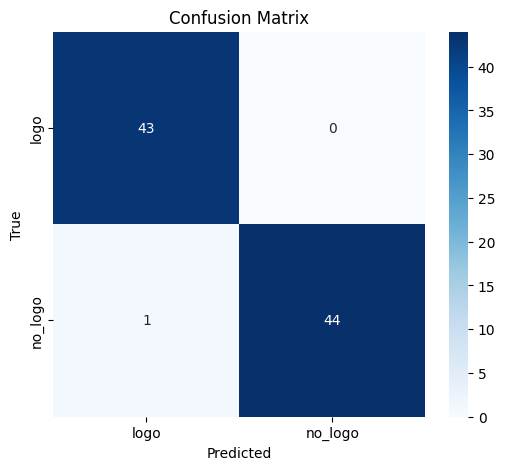

Model loaded: /kaggle/working/best_model.h5
Detected intervals (sec): [[17.0, 18.0]]


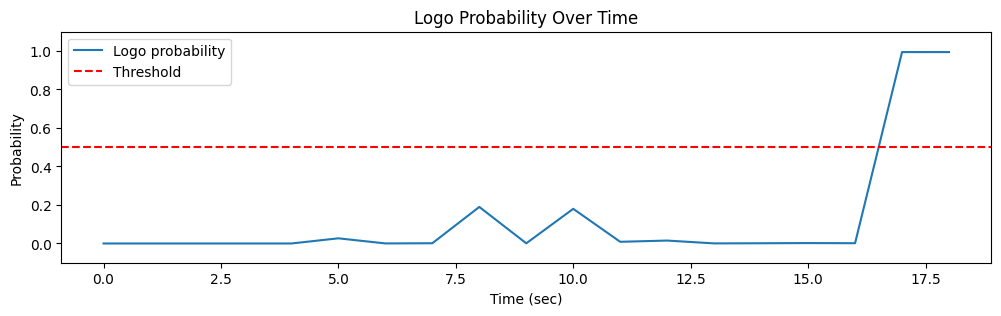

In [2]:
import os
import numpy as np
import tensorflow as tf
from pathlib import Path
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras import layers, Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import cv2


DATA_FOLDER = '/kaggle/input/myapple-data/Apple-data'  
MODEL_SAVE_PATH = "/kaggle/working/best_model.h5" 
EPOCHS_NUM = 10
BATCH_SIZE_NUM = 16
LEARNING_RATE = 1e-4
USE_IMAGENET_WEIGHTS = True      # Load pretrained Xception weights 
ENABLE_MIXED_PRECISION = False   
IMAGE_DIM = (299, 299)
MODEL_INPUT_SHAPE = (299, 299, 3)

# Enable mixed precision training
if ENABLE_MIXED_PRECISION:
    from tensorflow.keras import mixed_precision
    mixed_precision.set_global_policy('mixed_float16')
    print("Mixed precision activated")

AUTOTUNE = tf.data.AUTOTUNE


# ==============================================================
#                    IMAGE PROCESSING PIPELINE

def load_and_resize_image(file_path, label, target_size):
    """
    Reads an image from disk, decodes it, normalizes it, and resizes it
    to the predefined input size.
    """
    img = tf.io.read_file(file_path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.convert_image_dtype(img, tf.float32) 
    img = tf.image.resize(img, target_size)
    return img, label


def apply_augmentation(image, label):
    """
    Applies random image augmentation (rotation, flip, brightness, contrast).
    Used only during training to improve model generalization.
    """
    try:
        import tensorflow_addons as tfa
        angle = tf.random.uniform([], -0.1, 0.1)
        image = tfa.image.rotate(image, angle)
    except Exception:
        pass

    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_brightness(image, 0.1)
    image = tf.image.random_contrast(image, 0.9, 1.1)
    return image, label


def create_tf_dataset(file_paths, labels, batch_size=BATCH_SIZE_NUM,
                      shuffle=True, target_size=(299,299), augment=False):
    """
    Builds a high-performance TensorFlow dataset pipeline for training and validation.
    Supports shuffling, augmentation, batching, and prefetching.
    """
    dataset = tf.data.Dataset.from_tensor_slices((file_paths, labels))
    if shuffle:
        dataset = dataset.shuffle(len(file_paths))

    dataset = dataset.map(
        lambda f, l: load_and_resize_image(f, l, target_size),
        num_parallel_calls=AUTOTUNE
    )

    if augment:
        dataset = dataset.map(apply_augmentation, num_parallel_calls=AUTOTUNE)

    dataset = dataset.batch(batch_size).prefetch(AUTOTUNE)
    return dataset


# ==============================================================
#                 CUSTOM XCEPTION-LIKE NETWORK

def separable_conv_block(inputs, filters, kernel_size=(3,3)):
    """
    A Xception-style separable convolution block with BatchNorm + ReLU.
    """
    x = layers.SeparableConv2D(filters, kernel_size, padding='same', use_bias=False)(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    return x


def build_input_module(inputs):
    """
    Builds the initial stem of the network, including several convolution
    blocks and downsampling residual connections.
    """
    # Initial entry flow
    x = layers.Conv2D(32, (3,3), strides=2, padding='same', use_bias=False)(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    x = layers.Conv2D(64, (3,3), padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    # Residual block 1
    residual = layers.Conv2D(128, (1,1), strides=2, padding='same', use_bias=False)(x)
    residual = layers.BatchNormalization()(residual)

    x = separable_conv_block(x, 128)
    x = separable_conv_block(x, 128)
    x = layers.MaxPooling2D((3,3), strides=2, padding='same')(x)
    x = layers.add([x, residual])

    # Residual block 2
    residual = layers.Conv2D(256, (1,1), strides=2, padding='same', use_bias=False)(x)
    residual = layers.BatchNormalization()(residual)

    x = separable_conv_block(x, 256)
    x = separable_conv_block(x, 256)
    x = layers.MaxPooling2D((3,3), strides=2, padding='same')(x)
    x = layers.add([x, residual])

    # Residual block 3
    residual = layers.Conv2D(728, (1,1), strides=2, padding='same', use_bias=False)(x)
    residual = layers.BatchNormalization()(residual)

    x = separable_conv_block(x, 728)
    x = separable_conv_block(x, 728)
    x = layers.MaxPooling2D((3,3), strides=2, padding='same')(x)
    x = layers.add([x, residual])

    return x


def build_centr_module(x, repeat_times=8):
    """
    Builds the middle flow (Xception-like), consisting of repeated
    residual separable convolution blocks.
    """
    for _ in range(repeat_times):
        residual = x
        x = separable_conv_block(x, 728)
        x = separable_conv_block(x, 728)
        x = separable_conv_block(x, 728)
        x = layers.add([x, residual])
    return x


def build_output_module(x, num_classes):
    """
    Builds the exit flow: final conv layers, global pooling, dropout,
    and classification head.
    """
    residual = layers.Conv2D(1024, (1,1), strides=2, padding='same', use_bias=False)(x)
    residual = layers.BatchNormalization()(residual)

    x = separable_conv_block(x, 728)
    x = separable_conv_block(x, 1024)
    x = layers.MaxPooling2D((3,3), strides=2, padding='same')(x)
    x = layers.add([x, residual])

    # Final feature extraction layers
    x = layers.SeparableConv2D(1536, (3,3), padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    x = layers.SeparableConv2D(2048, (3,3), padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.5)(x)

    # Output head
    if num_classes == 1:
        output_layer = layers.Dense(1, activation='sigmoid')(x)
    else:
        output_layer = layers.Dense(num_classes, activation='softmax')(x)
    return output_layer


def build_custom_xception_model(input_shape, num_classes, use_imagenet=False):
    """
    Assembles the full Xception-like model architecture and optionally loads
    pretrained ImageNet weights (without the top layers).
    """
    inputs = layers.Input(shape=input_shape)
    x = build_input_module(inputs)
    x = build_centr_module(x)
    outputs = build_output_module(x, num_classes)

    model = Model(inputs=inputs, outputs=outputs)

    # Load pretrained ImageNet weights partially
    if use_imagenet:
        try:
            WEIGHT_URL = "https://storage.googleapis.com/tensorflow/keras-applications/xception/xception_weights_tf_dim_ordering_tf_kernels_notop.h5"
            fname = tf.keras.utils.get_file('xception_notop.h5', WEIGHT_URL)
            model.load_weights(fname, by_name=True, skip_mismatch=True)
            print("ImageNet weights loaded successfully.")
        except Exception as e:
            print("Failed to load ImageNet weights:", e)

    return model


# ==============================================================
#                    DATASET PREPARATION UTILITIES

def collect_paths(base_dir, dataset_split):
    """
    Collects all image file paths and corresponding class labels from:
    base_dir / dataset_split / class_name / *.jpg
    """
    img_paths, img_labels = [], []
    base_folder = Path(base_dir, dataset_split)

    if not base_folder.exists():
        print(f"ERROR: Folder {base_folder} does not exist!")
        return [], []

    for cls_name in sorted([d.name for d in base_folder.iterdir() if d.is_dir()]):
        for file in (base_folder / cls_name).glob('*.*'):
            img_paths.append(str(file))
            img_labels.append(cls_name)

    return img_paths, img_labels


def encode_class_labels(labels_list):
    """
    Encodes class names into numeric labels using LabelEncoder.
    """
    encoder = LabelEncoder()
    encoded_labels = encoder.fit_transform(labels_list)
    return encoded_labels, encoder


print("Collecting images...")
train_files, train_labels = collect_paths(DATA_FOLDER, 'train')
val_files, val_labels = collect_paths(DATA_FOLDER, 'val')

print(f"Train: {len(train_files)}, Validation: {len(val_files)}")

y_train, label_encoder = encode_class_labels(train_labels)
y_val = label_encoder.transform(val_labels)

num_classes_total = 1 if len(label_encoder.classes_) == 2 else len(label_encoder.classes_)

# Build TF datasets
train_dataset = create_tf_dataset(train_files, y_train, batch_size=BATCH_SIZE_NUM,
                                  target_size=IMAGE_DIM, augment=True)
val_dataset = create_tf_dataset(val_files, y_val, batch_size=BATCH_SIZE_NUM,
                                target_size=IMAGE_DIM, augment=False)


# ==============================================================
#                     MODEL COMPILATION

print("Building model...")
model_net = build_custom_xception_model(MODEL_INPUT_SHAPE, num_classes_total, USE_IMAGENET_WEIGHTS)

loss_function = (
    'binary_crossentropy' if num_classes_total == 1 else 'sparse_categorical_crossentropy'
)

model_net.compile(
    optimizer=Adam(LEARNING_RATE),
    loss=loss_function,
    metrics=['accuracy']
)


# ==============================================================
#                          CALLBACKS

checkpoint_cb = ModelCheckpoint(
    MODEL_SAVE_PATH,
    monitor='val_accuracy',
    save_best_only=True,
    save_weights_only=False
)

reduce_lr_cb = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3
)

early_stop_cb = EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True
)


# ==============================================================
#                          TRAINING

print("Starting training...")
history = model_net.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS_NUM,
    callbacks=[checkpoint_cb, reduce_lr_cb, early_stop_cb]
)
print("Training completed.")


# ==============================================================
#                       MODEL EVALUATION

print("\n--- Model Evaluation ---")
best_model = tf.keras.models.load_model(MODEL_SAVE_PATH)
print("Model loaded:", MODEL_SAVE_PATH)

y_true_list, y_pred_list = [], []

# Iterate through validation dataset and collect predictions
for images_batch, labels_batch in val_dataset:
    preds = best_model.predict(images_batch)

    if num_classes_total == 1:
        preds = (preds > 0.5).astype("int32").flatten()
        labels_batch = labels_batch.numpy().flatten()
    else:
        preds = np.argmax(preds, axis=1)
        labels_batch = labels_batch.numpy()

    y_true_list.extend(labels_batch)
    y_pred_list.extend(preds)

# Convert to arrays
y_true_array = np.array(y_true_list)
y_pred_array = np.array(y_pred_list)

# Compute evaluation metrics
acc_score = accuracy_score(y_true_array, y_pred_array)
prec_score = precision_score(y_true_array, y_pred_array,
                             average='binary' if num_classes_total==1 else 'weighted')
rec_score = recall_score(y_true_array, y_pred_array,
                         average='binary' if num_classes_total==1 else 'weighted')
f1_score_val = f1_score(y_true_array, y_pred_array,
                        average='binary' if num_classes_total==1 else 'weighted')

print(f"Accuracy:  {acc_score:.4f}")
print(f"Precision: {prec_score:.4f}")
print(f"Recall:    {rec_score:.4f}")
print(f"F1-score:  {f1_score_val:.4f}")

# Plot confusion matrix
conf_matrix = confusion_matrix(y_true_array, y_pred_array)
plt.figure(figsize=(6,5))
sns.heatmap(
    conf_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


# ==============================================================
#                     VIDEO PROCESSING PIPELINE

def extract_frames(video_file, frame_rate=1):
    """
    Extracts frames from video at the specified sampling rate.
    Yields: (frame_index, frame_img, timestamp_in_seconds).
    """
    cap = cv2.VideoCapture(str(video_file))
    fps = cap.get(cv2.CAP_PROP_FPS) or 25
    frame_index = 0

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        step = max(int(fps // frame_rate), 1)

        if frame_index % step == 0:
            yield frame_index, frame, frame_index / fps

        frame_index += 1

    cap.release()


def detect_logo_intervals(predictions_bool, times_sec, min_duration=0.5, merge_gap=0.5):
    """
    Groups consecutive logo detections into continuous time intervals.
    Automatically merges intervals separated by small gaps.
    """
    intervals = []
    start_time = None
    prev_time = None

    for pred, t in zip(predictions_bool, times_sec):
        if pred and start_time is None:
            start_time = t
        elif not pred and start_time is not None:
            end_time = prev_time
            if end_time - start_time >= min_duration:
                intervals.append([start_time, end_time])
            start_time = None
        prev_time = t

    # Handle case where video ends during detection
    if start_time is not None and t - start_time >= min_duration:
        intervals.append([start_time, t])

    # Merge nearby intervals
    merged_intervals = []
    for s, e in intervals:
        if not merged_intervals:
            merged_intervals.append([s, e])
        else:
            if s - merged_intervals[-1][1] <= merge_gap:
                merged_intervals[-1][1] = e
            else:
                merged_intervals.append([s, e])

    return merged_intervals


def analyze_video(video_path, model_path, threshold=0.5, frame_rate=1):
    """
    Runs the trained model on a video, predicts logo presence frame-by-frame,
    aggregates detections into time intervals, and plots probability curve.
    """
    model = tf.keras.models.load_model(model_path)
    print("Model loaded:", model_path)

    preds_prob = []
    preds_bool = []
    times = []

    # Process frames
    for idx, frame, sec in extract_frames(video_path, frame_rate):
        img_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        img_resized = tf.image.resize(img_rgb, (299,299))
        img_norm = tf.cast(img_resized, tf.float32) / 255.0
        img_batch = np.expand_dims(img_norm.numpy(), axis=0)

        prob = model.predict(img_batch, verbose=0).ravel()[0]

        preds_prob.append(prob)
        preds_bool.append(prob >= threshold)
        times.append(sec)

    # Detect continuous intervals of logo presence
    logo_intervals = detect_logo_intervals(preds_bool, times)
    print("Detected intervals (sec):", logo_intervals)

    # Plot probability over time
    plt.figure(figsize=(12,3))
    plt.plot(times, preds_prob, label='Logo probability')
    plt.axhline(threshold, color='red', linestyle='--', label='Threshold')
    plt.xlabel("Time (sec)")
    plt.ylabel("Probability")
    plt.title("Logo Probability Over Time")
    plt.legend()
    plt.ylim(-0.1,1.1)
    plt.show()

    return logo_intervals


# ==============================================================
#                        MAIN EXECUTION

if __name__ == '__main__':
    video_file = '/kaggle/input/myapple-data/Apple-data/apple_2.mp4'
    weights_file = '/kaggle/working/best_model.h5'

    # Analyze logo presence in the video
    intervals = analyze_video(video_file, weights_file, threshold=0.5, frame_rate=1)